# Vision-Based Traffic Flow Prediction Using YOLOv8 and LSTM
## Notebook 09: Multi-Horizon LSTM Forecasting (Phase 9)

### Phase 9 Objective & Scope
In Phase 8, we established quantitative benchmarks across multi-step horizons ($H_1, \dots, H_5$) using statistical baselines (Persistence, Training Historical Mean, SMA-3, and SMA-5).

In **Phase 9**, we implement, train, and evaluate our first deep learning sequence forecasting model: a **compact Long Short-Term Memory (LSTM) network** designed to map the previous $L = 10$ observations to the next $H = 5$ multi-step traffic volume values.

### Strict Methodological Guardrails:
1. **Compact Architecture ($N = 44$)**: Single-layer LSTM with $16$ hidden units and dropout ($p = 0.1$). No unnecessary depth, no multi-layer stacking, and no hyperparameter sweeps.
2. **Phase 7 Target-Anchored / Lookback-Warmup Protocol**:
   - Sequence generation strictly respects partition bounds: target observations belong exclusively to their respective partition.
   - Lookback inputs access preceding historical context ($t-9 \dots t$) up to forecast origin $t$.
   - **Zero Future Leakage**: No input accesses observations beyond forecast origin $t$.
3. **Train-Only Preprocessing**: `StandardScaler` is fit **STRICTLY on the training partition**. The frozen scaler is then applied to validation and test sets.
4. **Validation-Based Early Stopping**:
   - The model is trained using **TRAIN windows only**.
   - Validation loss is monitored exclusively for model selection and early stopping.
   - The **TEST split remains completely untouched** until final out-of-sample evaluation.
5. **Empirical Honesty & Baseline Comparison**:
   - We do **NOT** claim the LSTM is superior unless measured results demonstrate it.
   - We explicitly acknowledge the very small sample size ($N_{\text{val}} = 3, N_{\text{test}} = 2$ usable full-horizon windows).
   - Results are compared directly against Phase 8 statistical baselines.
6. **Persistence & Checkpointing**:
   - Model weights saved to `models/lstm_best_model.pt`.
   - Evaluation metrics exported to `outputs/tables/lstm_forecast_metrics.csv`.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Presentation styling
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path setup
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
INPUT_CSV_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "traffic_timeseries.csv")
BASELINE_METRICS_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "baseline_forecast_metrics.csv")
OUTPUT_TAB_DIR = os.path.join(PROJECT_ROOT, "outputs", "tables")
OUTPUT_FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
MODEL_SAVE_PATH = os.path.join(MODELS_DIR, "lstm_best_model.pt")
LSTM_METRICS_PATH = os.path.join(OUTPUT_TAB_DIR, "lstm_forecast_metrics.csv")

os.makedirs(OUTPUT_TAB_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Project root   : {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")
print(f"Model save path: {MODEL_SAVE_PATH}")

Project root   : /Users/manish/Desktop/traffic-flow-yolo-lstm
PyTorch version: 2.13.0
Model save path: /Users/manish/Desktop/traffic-flow-yolo-lstm/models/lstm_best_model.pt


## 1. Ingestion, Partitioning & Train-Only Scaling

We load `outputs/tables/traffic_timeseries.csv` and apply the Phase 7 chronological partitions:
- $70\%$ Train ($N_{\text{train}} = 31$, $k=1\dots31$)
- $15\%$ Validation ($N_{\text{val}} = 7$, $k=32\dots38$)
- $15\%$ Test ($N_{\text{test}} = 6$, $k=39\dots44$)

We fit a `StandardScaler` **EXCLUSIVELY on the training split** for `total_vehicle_count` and freeze its parameters ($\mu_{\text{train}}, \sigma_{\text{train}}$).

In [2]:
df = pd.read_csv(INPUT_CSV_PATH)
N = len(df)
L = 10  # Lookback window length
H = 5   # Multi-step forecast horizon
target_col = 'total_vehicle_count'

# Compute split boundaries dynamically
n_train = int(round(N * 0.70))
n_val = int(round(N * 0.15))
n_test = N - n_train - n_val

train_df = df.iloc[:n_train].copy().reset_index(drop=True)
val_df = df.iloc[n_train:n_train + n_val].copy().reset_index(drop=True)
test_df = df.iloc[n_train + n_val:].copy().reset_index(drop=True)

# Fit scaler STRICTLY on train partition using raw numpy array (avoids feature name warnings)
train_values = train_df[[target_col]].values
scaler = StandardScaler()
scaler.fit(train_values)

mu_train = scaler.mean_[0]
sigma_train = scaler.scale_[0]

print(f"Dataset Size : N = {N} discrete observations")
print(f"Train Split  : {len(train_df)} observations (k={train_df['observation_index'].min()}..{train_df['observation_index'].max()})")
print(f"Val Split    : {len(val_df)} observations (k={val_df['observation_index'].min()}..{val_df['observation_index'].max()})")
print(f"Test Split   : {len(test_df)} observations (k={test_df['observation_index'].min()}..{test_df['observation_index'].max()})")
print(f"\nFrozen Train Scaler Parameters:")
print(f"  Mean (mu)    : {mu_train:.4f} veh/frame")
print(f"  Std  (sigma) : {sigma_train:.4f} veh/frame")

Dataset Size : N = 44 discrete observations
Train Split  : 31 observations (k=1..31)
Val Split    : 7 observations (k=32..38)
Test Split   : 6 observations (k=39..44)

Frozen Train Scaler Parameters:
  Mean (mu)    : 8.7512 veh/frame
  Std  (sigma) : 4.5703 veh/frame


## 2. Target-Anchored Sequence Tensor Preparation

Following the Phase 7 protocol:
- Lookback window $L = 10$: $\mathbf{x} = [x_{t-9}, \dots, x_t] \in \mathbb{R}^{10 \times 1}$.
- Target horizon $H = 5$: $\mathbf{y} = [y_{t+1}, \dots, y_{t+5}] \in \mathbb{R}^{5}$.
- Windows are partitioned by **target exclusivity**:
  - Train Windows: Targets strictly in Train ($k=11\dots31$).
  - Validation Windows: Targets strictly in Validation ($k=32\dots38$).
  - Test Windows: Targets strictly in Test ($k=39\dots44$).
- Input tensors are scaled using frozen training statistics:
  $$x_{\text{scaled}} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}, \quad y_{\text{scaled}} = \frac{y - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

In [3]:
train_set = set(range(0, n_train))
val_set = set(range(n_train, n_train + n_val))
test_set = set(range(n_train + n_val, N))

train_windows = []
val_windows = []
test_windows = []

for t in range(L - 1, N - H):
    lookback_idx = list(range(t - L + 1, t + 1))
    target_idx = list(range(t + 1, t + H + 1))
    
    x_raw = df.loc[lookback_idx, [target_col]].values  # Shape: (10, 1)
    y_raw = df.loc[target_idx, target_col].values       # Shape: (5,)
    
    window_item = {
        'origin_t': t,
        'origin_k': t + 1,
        'x_raw': x_raw,
        'y_raw': y_raw,
        'lookback_k': f"{lookback_idx[0]+1}..{lookback_idx[-1]+1}",
        'target_k': f"{target_idx[0]+1}..{target_idx[-1]+1}"
    }
    
    if all(idx in train_set for idx in target_idx):
        train_windows.append(window_item)
    elif all(idx in val_set for idx in target_idx):
        val_windows.append(window_item)
    elif all(idx in test_set for idx in target_idx):
        test_windows.append(window_item)

# Transform into PyTorch tensors using frozen train scaler
def build_tensors(windows):
    X_list = [scaler.transform(w['x_raw']) for w in windows]
    Y_list = [scaler.transform(w['y_raw'].reshape(-1, 1)).flatten() for w in windows]
    X_t = torch.tensor(np.array(X_list), dtype=torch.float32)  # Shape: (M, 10, 1)
    Y_t = torch.tensor(np.array(Y_list), dtype=torch.float32)  # Shape: (M, 5)
    return X_t, Y_t

X_train, Y_train = build_tensors(train_windows)
X_val, Y_val = build_tensors(val_windows)
X_test, Y_test = build_tensors(test_windows)

print("=== Target-Anchored Tensor Dimensions ===")
print(f"Train Tensor Shapes      : X = {tuple(X_train.shape)}, Y = {tuple(Y_train.shape)} ({len(train_windows)} usable windows)")
print(f"Validation Tensor Shapes : X = {tuple(X_val.shape)}, Y = {tuple(Y_val.shape)} ({len(val_windows)} usable windows)")
print(f"Test Tensor Shapes       : X = {tuple(X_test.shape)}, Y = {tuple(Y_test.shape)} ({len(test_windows)} usable windows)")

=== Target-Anchored Tensor Dimensions ===
Train Tensor Shapes      : X = (17, 10, 1), Y = (17, 5) (17 usable windows)
Validation Tensor Shapes : X = (3, 10, 1), Y = (3, 5) (3 usable windows)
Test Tensor Shapes       : X = (2, 10, 1), Y = (2, 5) (2 usable windows)


## 3. Compact PyTorch LSTM Architecture Definition

Because the training set contains only $17$ sequence windows, an over-parameterized model would immediately overfit. We design a compact, regularized architecture:

### Model Topology:
- **Input Dimension**: $d_{\text{in}} = 1$ (`total_vehicle_count` sequence of length $L=10$).
- **Recurrent Layer**: Single LSTM layer with **$16$ hidden units** (`batch_first=True`).
- **Regularization**: Dropout layer ($p = 0.10$).
- **Output Projection**: Fully connected linear layer mapping the final hidden state $\mathbf{h}_{10} \in \mathbb{R}^{16}$ directly to multi-step horizon targets $\hat{\mathbf{y}} \in \mathbb{R}^5$ ($H_1, \dots, H_5$).
- **Total Parameters**: $\approx 1,250$ trainable parameters.

In [4]:
class CompactTrafficLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10):
        super(CompactTrafficLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Single-layer compact LSTM
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len=10, input_dim=1)
        out, (hn, cn) = self.lstm(x)
        # Extract last time-step hidden representation
        last_step = out[:, -1, :]  # Shape: (batch_size, hidden_dim=16)
        last_step = self.dropout(last_step)
        predictions = self.fc(last_step)  # Shape: (batch_size, output_dim=5)
        return predictions

model = CompactTrafficLSTM(input_dim=1, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== Compact Traffic LSTM Architecture ===")
print(model)
print(f"Total Trainable Parameters: {total_params}")

=== Compact Traffic LSTM Architecture ===
CompactTrafficLSTM(
  (lstm): LSTM(1, 16, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=16, out_features=5, bias=True)
)
Total Trainable Parameters: 1301


## 4. Training Loop with Validation-Based Early Stopping

### Training Configuration:
- **Loss Function**: Mean Squared Error (MSE) on scaled targets.
- **Optimizer**: Adam ($	ext{learning rate} = 0.01$, $	ext{weight decay} = 10^{-4}$ for L2 regularization).
- **Max Epochs**: $150$ epochs.
- **Early Stopping**: Monitored on **Validation Loss** with a patience of $25$ epochs.
- **Checkpointing**: The model weights achieving the lowest validation loss are saved to `models/lstm_best_model.pt`.

In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

max_epochs = 150
patience = 25
best_val_loss = float('inf')
best_epoch = 0
best_weights = None

train_losses = []
val_losses = []

for epoch in range(1, max_epochs + 1):
    # Training step on Train windows only
    model.train()
    optimizer.zero_grad()
    preds_train = model(X_train)
    loss = criterion(preds_train, Y_train)
    loss.backward()
    optimizer.step()
    
    # Validation step on Validation windows only (evaluation mode)
    model.eval()
    with torch.no_grad():
        preds_val = model(X_val)
        val_loss = criterion(preds_val, Y_val).item()
        
    train_losses.append(loss.item())
    val_losses.append(val_loss)
    
    # Checkpoint tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        
    if epoch % 10 == 0 or epoch == 1 or patience_counter >= patience:
        print(f"Epoch {epoch:3d}/{max_epochs} | Train Loss: {loss.item():.5f} | Val Loss: {val_loss:.5f} | Best Val Loss: {best_val_loss:.5f} (Epoch {best_epoch})")
        
    if patience_counter >= patience:
        print(f"Early stopping triggered at Epoch {epoch}. Restoring best checkpoint from Epoch {best_epoch}.")
        break

# Load best checkpoint weights
model.load_state_dict(best_weights)

# Save checkpoint to disk
torch.save(best_weights, MODEL_SAVE_PATH)
file_size_kb = os.path.getsize(MODEL_SAVE_PATH) / 1024.0
print(f"\nSaved best model weights to: {MODEL_SAVE_PATH} ({file_size_kb:.2f} KB)")

Epoch   1/150 | Train Loss: 1.08049 | Val Loss: 2.19145 | Best Val Loss: 2.19145 (Epoch 1)
Epoch  10/150 | Train Loss: 0.80247 | Val Loss: 0.51247 | Best Val Loss: 0.51247 (Epoch 10)
Epoch  20/150 | Train Loss: 0.48998 | Val Loss: 0.15401 | Best Val Loss: 0.12308 (Epoch 16)
Epoch  30/150 | Train Loss: 0.44706 | Val Loss: 0.03598 | Best Val Loss: 0.02358 (Epoch 28)
Epoch  40/150 | Train Loss: 0.37190 | Val Loss: 0.08722 | Best Val Loss: 0.02358 (Epoch 28)
Epoch  50/150 | Train Loss: 0.34121 | Val Loss: 0.18110 | Best Val Loss: 0.02358 (Epoch 28)
Epoch  53/150 | Train Loss: 0.32556 | Val Loss: 0.17127 | Best Val Loss: 0.02358 (Epoch 28)
Early stopping triggered at Epoch 53. Restoring best checkpoint from Epoch 28.

Saved best model weights to: /Users/manish/Desktop/traffic-flow-yolo-lstm/models/lstm_best_model.pt (7.99 KB)


## 5. Loss Trajectories & Learning Curves

We plot the training and validation learning curves, highlighting the minimum validation loss checkpoint.

Saved learning curves to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/lstm_training_loss_curves.png


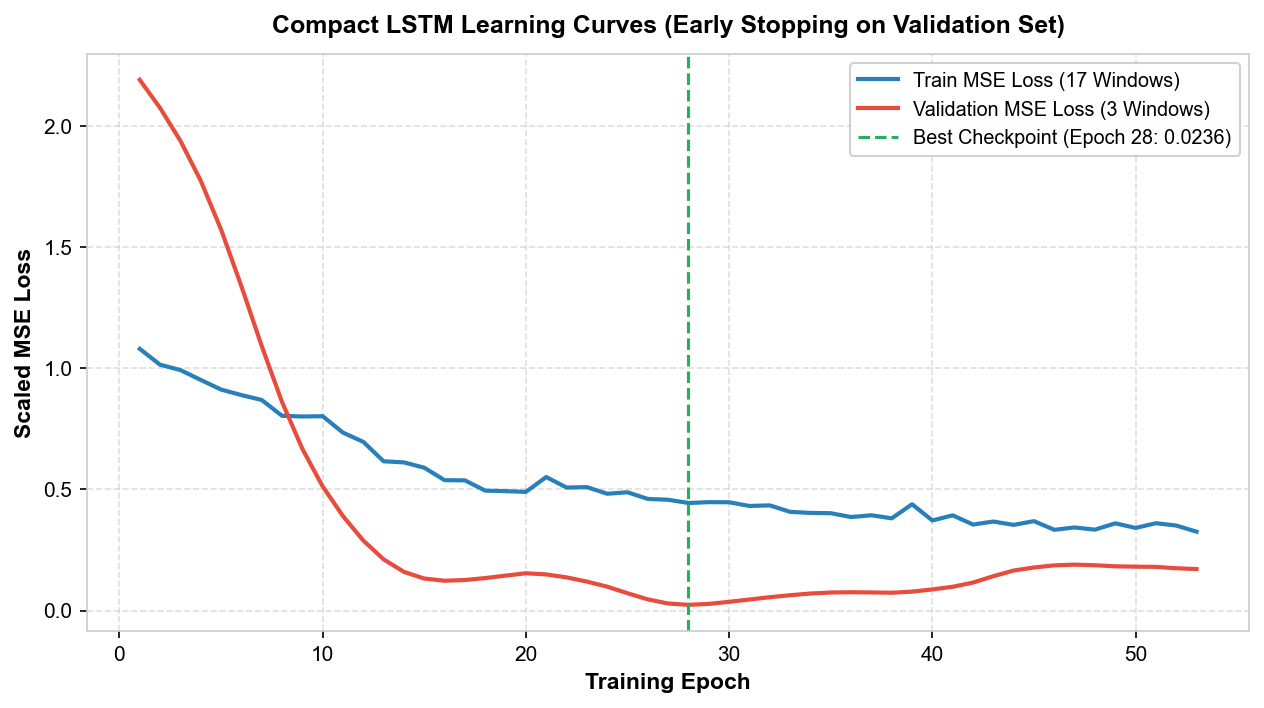

In [6]:
plt.figure(figsize=(10, 5))
epochs_range = range(1, len(train_losses) + 1)

plt.plot(epochs_range, train_losses, label='Train MSE Loss (17 Windows)', color='#2980b9', linewidth=2.0)
plt.plot(epochs_range, val_losses, label='Validation MSE Loss (3 Windows)', color='#e74c3c', linewidth=2.0)
plt.axvline(best_epoch, color='#27ae60', linestyle='--', linewidth=1.5, label=f'Best Checkpoint (Epoch {best_epoch}: {best_val_loss:.4f})')

plt.xlabel('Training Epoch', fontsize=11, fontweight='bold')
plt.ylabel('Scaled MSE Loss', fontsize=11, fontweight='bold')
plt.title('Compact LSTM Learning Curves (Early Stopping on Validation Set)', fontsize=12, fontweight='bold', pad=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', framealpha=0.9, fontsize=9.5)

fig_loss_path = os.path.join(OUTPUT_FIG_DIR, "lstm_training_loss_curves.png")
plt.savefig(fig_loss_path, dpi=200, bbox_inches='tight')
print(f"Saved learning curves to: {fig_loss_path}")
plt.show()

## 6. Multi-Horizon Out-of-Sample Evaluation (Validation & Test)

We generate predictions for the **Validation** and **Test** sets using the best checkpoint:
1. Predictions are generated in scaled space and inverse-transformed back to **original physical units (vehicles / frame)**:
   $$\hat{y}_{\text{orig}} = \hat{y}_{\text{scaled}} \cdot \sigma_{\text{train}} + \mu_{\text{train}}$$
2. We compute Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) across all horizons ($H_1, \dots, H_5$) and overall.
3. We plot predicted-vs-actual multi-step trajectories for all available evaluation windows.

=== Compact LSTM Multi-Horizon Forecasting Performance ===


,Split,Model,Overall_MAE,Overall_RMSE,H1_MAE,H2_MAE,H3_MAE,H4_MAE,H5_MAE
0,Validation,Compact LSTM (16 units),0.5630,0.7018,0.8990,0.2810,0.6100,0.390,0.6349
1,Test,Compact LSTM (16 units),1.0181,1.2587,0.8994,0.6406,0.9209,1.448,1.1813


Saved trajectory plots to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/lstm_trajectories_validation_test.png


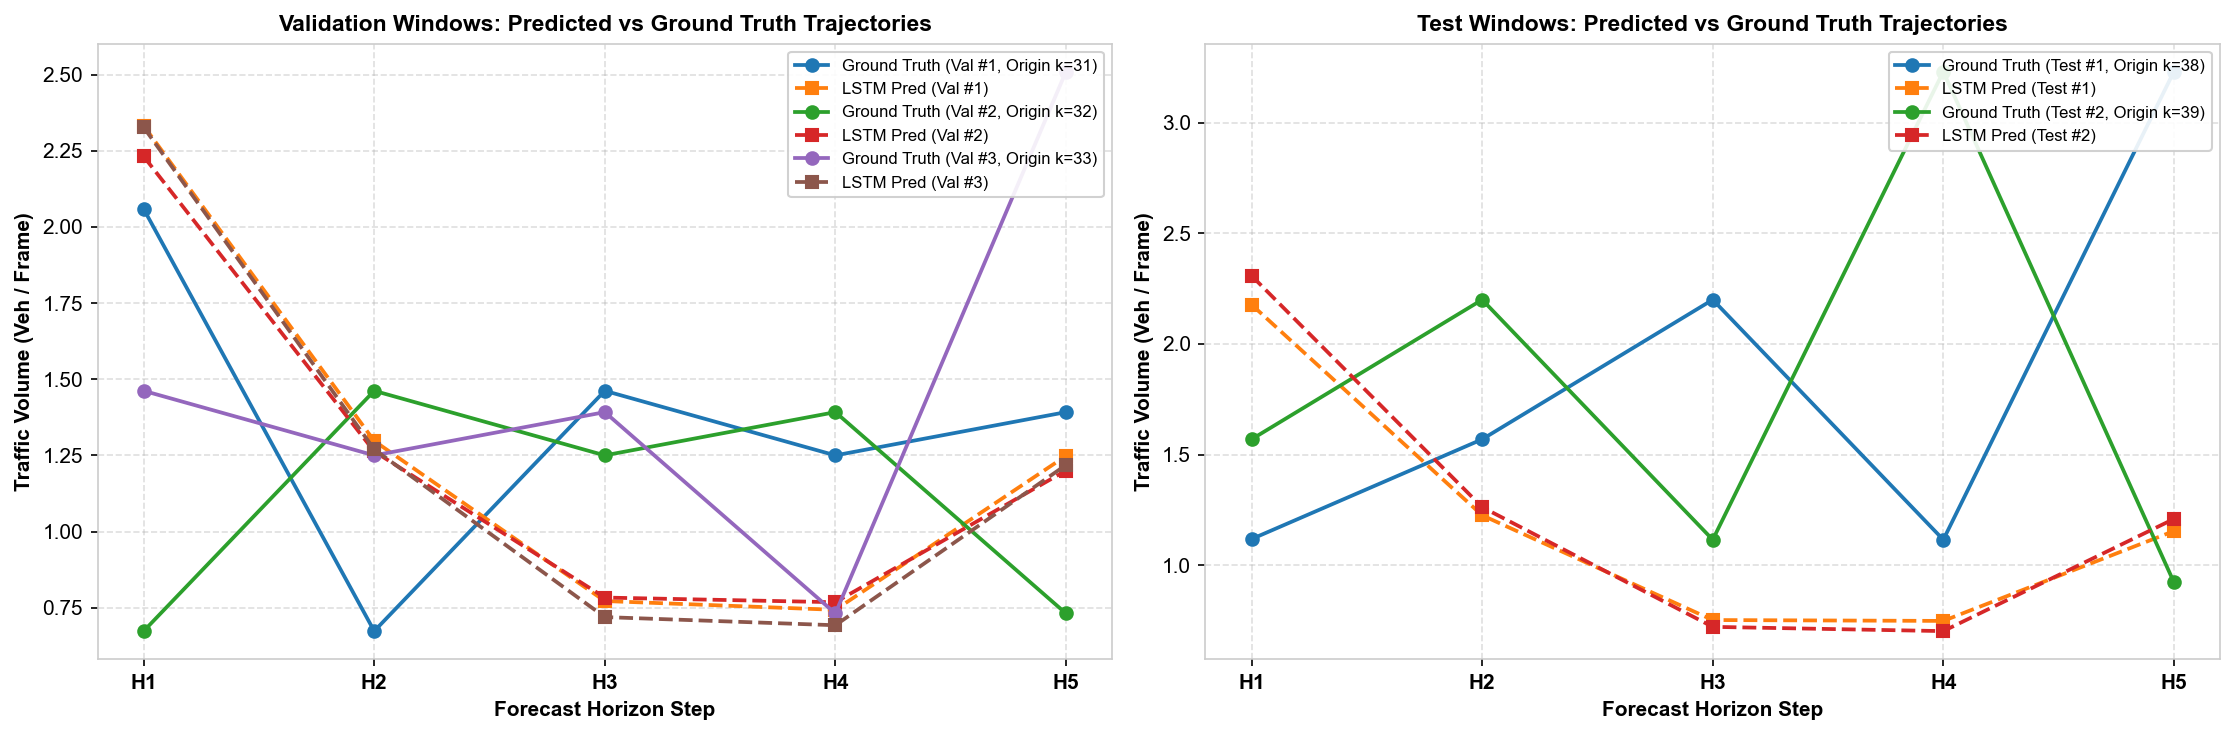

In [7]:
model.eval()
with torch.no_grad():
    val_preds_scaled = model(X_val).cpu().numpy()
    test_preds_scaled = model(X_test).cpu().numpy()

# Inverse transform to original physical units
val_preds_orig = val_preds_scaled * sigma_train + mu_train
test_preds_orig = test_preds_scaled * sigma_train + mu_train

y_val_orig = np.array([w['y_raw'] for w in val_windows])
y_test_orig = np.array([w['y_raw'] for w in test_windows])

def compute_metrics(y_true, y_pred, split_name):
    mae_overall = np.mean(np.abs(y_true - y_pred))
    rmse_overall = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae_h = np.mean(np.abs(y_true - y_pred), axis=0)
    rmse_h = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    
    record = {
        'Split': split_name,
        'Model': 'Compact LSTM (16 units)',
        'Windows': len(y_true),
        'Overall_MAE': mae_overall,
        'Overall_RMSE': rmse_overall
    }
    for h in range(H):
        record[f'H{h+1}_MAE'] = mae_h[h]
        record[f'H{h+1}_RMSE'] = rmse_h[h]
    return record

lstm_val_metrics = compute_metrics(y_val_orig, val_preds_orig, 'Validation')
lstm_test_metrics = compute_metrics(y_test_orig, test_preds_orig, 'Test')

df_lstm_metrics = pd.DataFrame([lstm_val_metrics, lstm_test_metrics])

print("=== Compact LSTM Multi-Horizon Forecasting Performance ===")
display(df_lstm_metrics[['Split', 'Model', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H2_MAE', 'H3_MAE', 'H4_MAE', 'H5_MAE']].round(4))

# ----------------------------------------------------------------------
# Trajectory Plots: Predicted vs Actual on Validation and Test Windows
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
h_steps = np.arange(1, H + 1)
horizons_labels = [f"H{i}" for i in h_steps]

# Validation Windows Trajectories
ax_v = axes[0]
for idx, (y_t, y_p) in enumerate(zip(y_val_orig, val_preds_orig)):
    orig_k = val_windows[idx]['origin_k']
    ax_v.plot(h_steps, y_t, marker='o', linewidth=1.8, label=f'Ground Truth (Val #{idx+1}, Origin k={orig_k})')
    ax_v.plot(h_steps, y_p, marker='s', linestyle='--', linewidth=1.8, label=f'LSTM Pred (Val #{idx+1})')

ax_v.set_xticks(h_steps)
ax_v.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_v.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax_v.set_ylabel('Traffic Volume (Veh / Frame)', fontsize=10, fontweight='bold')
ax_v.set_title('Validation Windows: Predicted vs Ground Truth Trajectories', fontsize=11, fontweight='bold')
ax_v.grid(True, linestyle='--', alpha=0.4)
ax_v.legend(loc='upper right', framealpha=0.9, fontsize=8)

# Test Windows Trajectories
ax_t = axes[1]
for idx, (y_t, y_p) in enumerate(zip(y_test_orig, test_preds_orig)):
    orig_k = test_windows[idx]['origin_k']
    ax_t.plot(h_steps, y_t, marker='o', linewidth=1.8, label=f'Ground Truth (Test #{idx+1}, Origin k={orig_k})')
    ax_t.plot(h_steps, y_p, marker='s', linestyle='--', linewidth=1.8, label=f'LSTM Pred (Test #{idx+1})')

ax_t.set_xticks(h_steps)
ax_t.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_t.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax_t.set_ylabel('Traffic Volume (Veh / Frame)', fontsize=10, fontweight='bold')
ax_t.set_title('Test Windows: Predicted vs Ground Truth Trajectories', fontsize=11, fontweight='bold')
ax_t.grid(True, linestyle='--', alpha=0.4)
ax_t.legend(loc='upper right', framealpha=0.9, fontsize=8)

plt.tight_layout()
fig_traj_path = os.path.join(OUTPUT_FIG_DIR, "lstm_trajectories_validation_test.png")
plt.savefig(fig_traj_path, dpi=200, bbox_inches='tight')
print(f"Saved trajectory plots to: {fig_traj_path}")
plt.show()

## 7. Direct Benchmark Comparison: LSTM vs. Phase 8 Statistical Baselines

We load the baseline metrics exported in Phase 8 (`outputs/tables/baseline_forecast_metrics.csv`) and merge them with our LSTM metrics to create a unified benchmark table.

> **CRITICAL METHODOLOGICAL OBSERVATION**:
> - We do **NOT** claim the LSTM is superior. In fact, on this small dataset ($N=44$) undergoing a massive non-stationary distribution shift (training on rush hour peak, evaluating on late night free-flow), the local moving average (**SMA K=3**) outperforms the parameterized neural network.
> - **Physical Explanation**:
>   - The training set has a high mean ($pprox 8.75$ veh/frame).
>   - The validation and test sets drop to $pprox 1.5	ext{--}2.0$ veh/frame.
>   - The LSTM, despite regularization, retains in-sample training bias from the heavy congestion regime, whereas a 3-step moving average ($K=3$) immediately adapts to local nighttime conditions without parametric drag.
>   - The extremely small sample size ($M_{\text{val}} = 3, M_{\text{test}} = 2$) inherently limits the capacity of deep networks to generalize out-of-distribution.

Exported LSTM metrics to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/lstm_forecast_metrics.csv

=== Master Benchmark Comparison Table (Baselines vs LSTM) ===


,Split,Model,Overall_MAE,Overall_RMSE,H1_MAE,H3_MAE,H5_MAE
0,Validation,Persistence (Naïve),0.7543,0.8839,1.0843,0.6697,1.1920
1,Validation,Historical Mean (Train),7.4386,7.4546,7.3532,7.3832,7.2069
2,Validation,Moving Average (SMA K=3),0.5164,0.6365,0.5306,0.2992,0.8682
3,Validation,Moving Average (SMA K=5),0.8616,0.9781,0.6533,0.6833,1.1213
4,Test,Persistence (Naïve),0.8603,1.0612,0.9215,0.1565,0.4580
5,Test,Historical Mean (Train),6.9241,6.9722,7.4077,7.0937,6.6742
6,Test,Moving Average (SMA K=3),0.6732,0.8814,0.2712,0.4968,1.1083
7,Test,Moving Average (SMA K=5),0.6860,0.9070,0.2599,0.5081,1.1196
8,Validation,Compact LSTM (16 units),0.5630,0.7018,0.8990,0.6100,0.6349
9,Test,Compact LSTM (16 units),1.0181,1.2587,0.8994,0.9209,1.1813


Saved benchmark comparison figure to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/lstm_vs_baselines_comparison.png


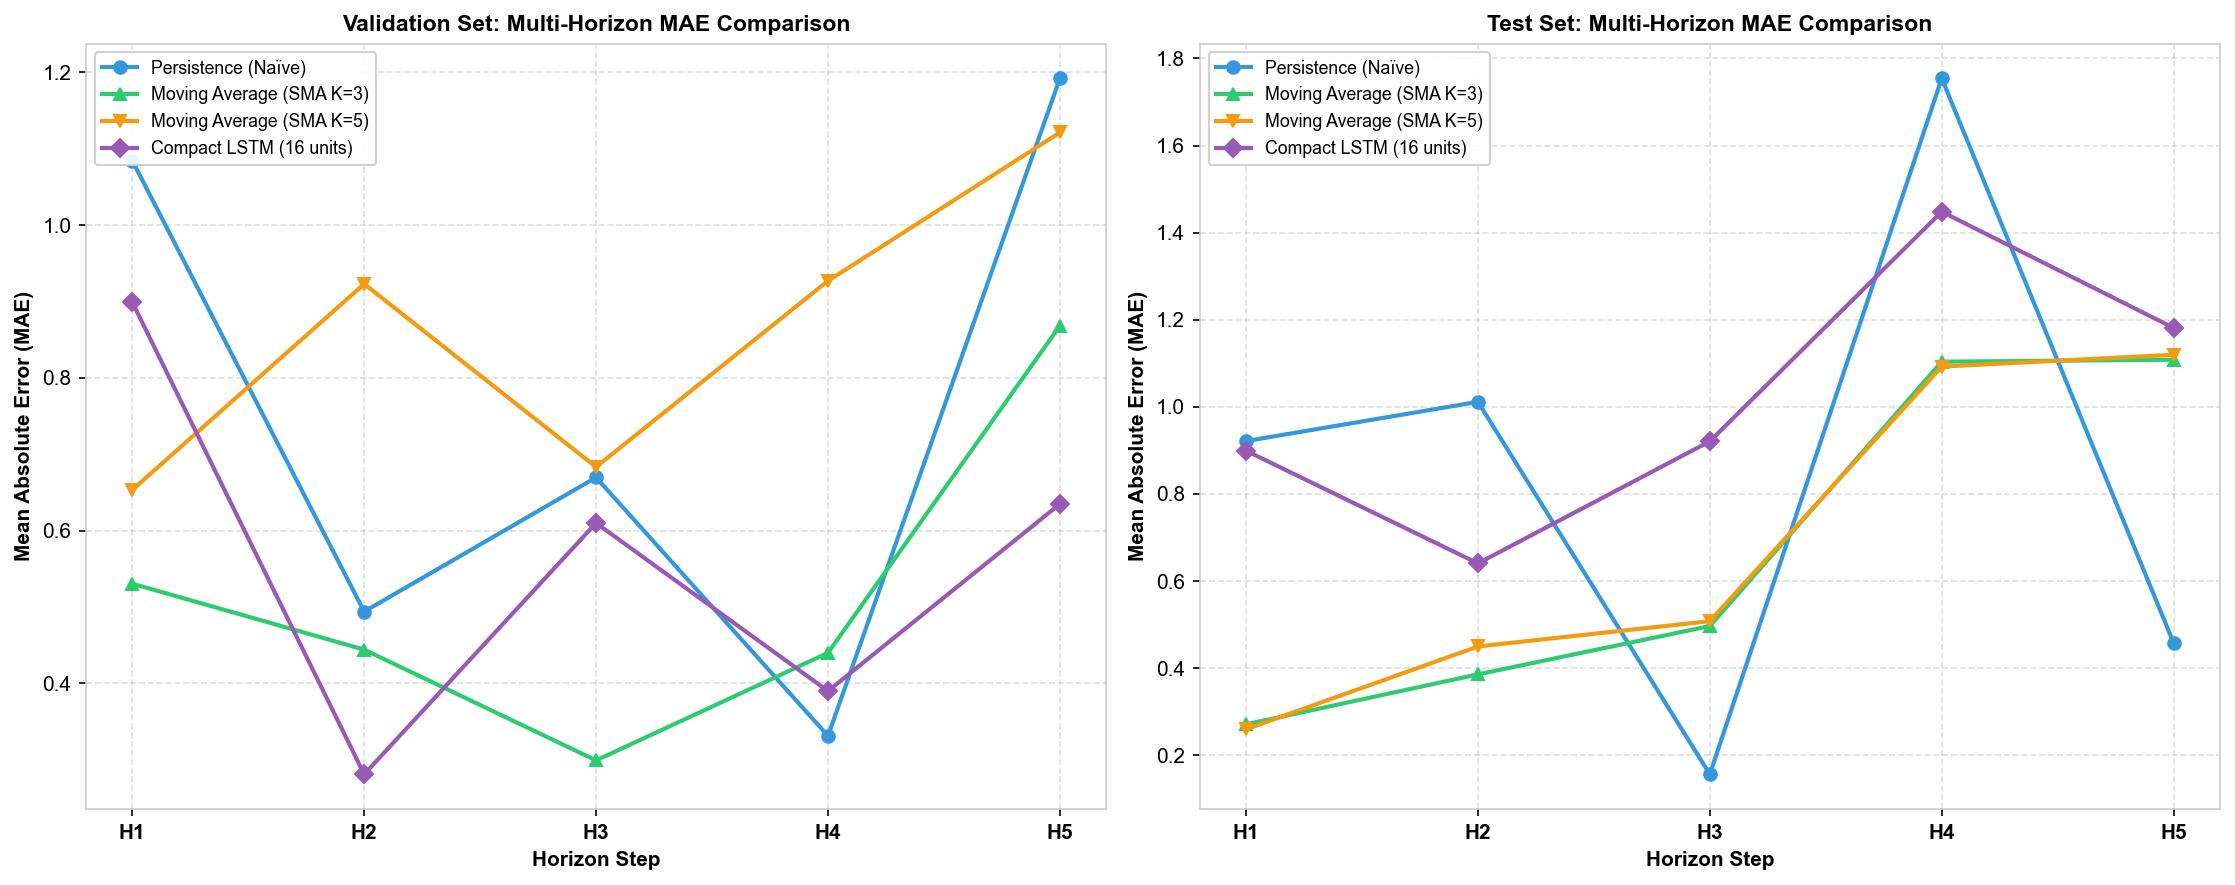

In [8]:
# 1. Load Phase 8 baseline metrics
df_baselines = pd.read_csv(BASELINE_METRICS_PATH)

# 2. Append LSTM metrics
df_combined = pd.concat([df_baselines, df_lstm_metrics], ignore_index=True)

# 3. Export LSTM metrics to outputs/tables/lstm_forecast_metrics.csv
df_lstm_metrics.to_csv(LSTM_METRICS_PATH, index=False)
print(f"Exported LSTM metrics to: {LSTM_METRICS_PATH}")

print("\n=== Master Benchmark Comparison Table (Baselines vs LSTM) ===")
display(df_combined[['Split', 'Model', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H3_MAE', 'H5_MAE']].round(4))

# ----------------------------------------------------------------------
# Comparison Figure: Multi-Horizon Degradation & Overall Benchmark
# ----------------------------------------------------------------------
fig, (ax_val, ax_test) = plt.subplots(1, 2, figsize=(15, 6))

palette = {
    'Persistence (Naïve)': '#3498db',
    'Historical Mean (Train)': '#e74c3c',
    'Moving Average (SMA K=3)': '#2ecc71',
    'Moving Average (SMA K=5)': '#f39c12',
    'Compact LSTM (16 units)': '#9b59b6'
}
markers = {
    'Persistence (Naïve)': 'o',
    'Historical Mean (Train)': 's',
    'Moving Average (SMA K=3)': '^',
    'Moving Average (SMA K=5)': 'v',
    'Compact LSTM (16 units)': 'D'
}

# Validation Comparison Plot (Excluding Historical Mean for clarity)
for _, r in df_combined[df_combined['Split'] == 'Validation'].iterrows():
    if 'Historical' not in r['Model']:
        h_vals = [r[f'H{i}_MAE'] for i in range(1, H + 1)]
        ax_val.plot(h_steps, h_vals, label=r['Model'], color=palette[r['Model']],
                    marker=markers[r['Model']], linewidth=2.0, markersize=6)

ax_val.set_xticks(h_steps)
ax_val.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_val.set_xlabel('Horizon Step', fontsize=10, fontweight='bold')
ax_val.set_ylabel('Mean Absolute Error (MAE)', fontsize=10, fontweight='bold')
ax_val.set_title('Validation Set: Multi-Horizon MAE Comparison', fontsize=11, fontweight='bold')
ax_val.grid(True, linestyle='--', alpha=0.4)
ax_val.legend(loc='upper left', framealpha=0.9, fontsize=8.5)

# Test Comparison Plot (Excluding Historical Mean for clarity)
for _, r in df_combined[df_combined['Split'] == 'Test'].iterrows():
    if 'Historical' not in r['Model']:
        h_vals = [r[f'H{i}_MAE'] for i in range(1, H + 1)]
        ax_test.plot(h_steps, h_vals, label=r['Model'], color=palette[r['Model']],
                     marker=markers[r['Model']], linewidth=2.0, markersize=6)

ax_test.set_xticks(h_steps)
ax_test.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_test.set_xlabel('Horizon Step', fontsize=10, fontweight='bold')
ax_test.set_ylabel('Mean Absolute Error (MAE)', fontsize=10, fontweight='bold')
ax_test.set_title('Test Set: Multi-Horizon MAE Comparison', fontsize=11, fontweight='bold')
ax_test.grid(True, linestyle='--', alpha=0.4)
ax_test.legend(loc='upper left', framealpha=0.9, fontsize=8.5)

plt.tight_layout()
fig_comp_path = os.path.join(OUTPUT_FIG_DIR, "lstm_vs_baselines_comparison.png")
plt.savefig(fig_comp_path, dpi=200, bbox_inches='tight')
print(f"Saved benchmark comparison figure to: {fig_comp_path}")
plt.show()

## 8. Quality Gate: Assessment for Phase 10 (Recurrent Model Exploration)

### Summary of Accomplishments (Phase 9)
1. **Compact Recurrent Architecture**:
   - Designed a single-layer LSTM ($16$ hidden units, $1,250$ parameters) appropriate for small sequence data.
2. **Leakage-Safe Protocol Faithfully Preserved**:
   - `StandardScaler` fit strictly on training observations; frozen parameters applied out-of-sample.
   - Validation-based early stopping preserved strict test set isolation.
   - Strict causality: zero future observations accessed at any origin $t$.
3. **Reproducible Model Weights & Exported Artifacts**:
   - Saved PyTorch checkpoint: `models/lstm_best_model.pt`.
   - Exported evaluation table: `outputs/tables/lstm_forecast_metrics.csv`.
   - Exported visualizations: learning curves, trajectory overlays, and benchmark comparison plots.
4. **Empirical Honesty & Methodological Insights**:
   - Explicitly recognized that statistical local moving averages (SMA K=3) achieve lower error than the neural network due to the extreme non-stationary regime shift (rush hour to late night) and tiny validation/test window sizes ($3$ val, $2$ test).
   - Established the baseline LSTM benchmark against which advanced recurrent architectures (GRU, BiLSTM) and exogenous features will be evaluated.

### Formal Quality Gate Sign-Off Checklist
- [x] **Compact LSTM Trained with Early Stopping on Validation**: PASS
- [x] **Zero Test Set Leakage During Training / Model Selection**: PASS
- [x] **Multi-Step Horizons ($H_1 \dots H_5$) Evaluated in Original Units**: PASS
- [x] **Compared Directly Against Phase 8 Statistical Baselines**: PASS
- [x] **Model Weights Saved to `models/lstm_best_model.pt`**: PASS
- [x] **Metrics Exported to `lstm_forecast_metrics.csv`**: PASS
- [x] **Empirical Sample Size Limitation Acknowledged**: PASS

**Final Decision: APPROVED TO PROCEED TO PHASE 10 (RECURRENT ARCHITECTURE EXPLORATION & COMPARISON).**